In [9]:
import numpy as np

#sets up the tridiagonal matrix to be solved using provided data points
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])             # Right-hand side vector
    return A, B, C, D

#solves the tridiagonal system using the thomas algoritm
def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

#evaluates the points of the cubic spline
def evaluate_spline(x_val, x, y, M):
    n = len(x)
    h = np.diff(x)
    # Find which interval x_val falls into
    for i in range(n-1):
        if x[i] <= x_val <= x[i+1]:
            term1 = (M[i] / (6 * h[i])) * (x[i+1] - x_val)**3
            term2 = (M[i+1] / (6 * h[i])) * (x_val - x[i])**3
            term3 = (y[i] / h[i] - (M[i] * h[i]) / 6) * (x[i+1] - x_val)
            term4 = (y[i+1] / h[i] - (M[i+1] * h[i]) / 6) * (x_val - x[i])
            return term1 + term2 + term3 + term4
    return None

Solution: [-4.36363636  5.45454545 -5.45454545  4.36363636]


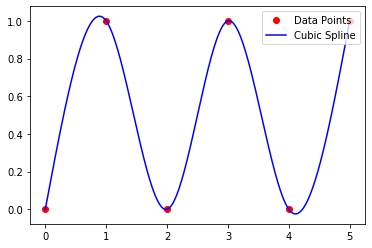

In [20]:

x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])

# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)
sol = thomas_algorithm(A, B, C, D)

#Adds zeros for M1 and Mn
M = np.zeros(len(sol)+2)
M[1:-1] = sol

#graph the custom cubic spline
import matplotlib.pyplot as plt

x_plot = np.arange(x[0], x[-1], 0.01)
y_plot = [evaluate_spline(val, x, y, M) for val in x_plot]

plt.plot(x, y, 'ro', label='Data Points')
plt.plot(x_plot, y_plot, 'b-', label='Cubic Spline')
plt.legend()
plt.show()